<a href="https://colab.research.google.com/github/Requiessss/DATA-science-prj/blob/main/Main_prj.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [8]:
import pandas as pd

arms_df = pd.read_csv("arms_transfers_clean.csv")

arms_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9756 entries, 0 to 9755
Data columns (total 12 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Recipient                       9756 non-null   object 
 1   Supplier                        9756 non-null   object 
 2   Year of order                   9756 non-null   int64  
 3   Number ordered                  9670 non-null   float64
 4   Weapon designation              9756 non-null   object 
 5   Weapon description              9756 non-null   object 
 6   Deliveries in the Year Range    9333 non-null   float64
 7   Year(s) of delivery             9333 non-null   object 
 8   status                          9756 non-null   object 
 9   SIPRI TIV per unit              9756 non-null   float64
 10  SIPRI TIV for total order       9756 non-null   float64
 11  SIPRI TIV of delivered weapons  9756 non-null   float64
dtypes: float64(5), int64(1), object(6)

In [14]:
arms_df.to_csv("arms_transfers_final_clean.csv", index=False)

In [15]:
arms_df.isna().sum()

,0
Recipient,0
Supplier,0
Year of order,0
Number ordered,85
Weapon designation,0
Weapon description,0
Deliveries in the Year Range,0
Year(s) of delivery,0
status,0
SIPRI TIV per unit,0


In [16]:
arms_df[arms_df["Number ordered"].isna()].head()

,Recipient,Supplier,Year of order,Number ordered,Weapon designation,Weapon description,Deliveries in the Year Range,Year(s) of delivery,status,SIPRI TIV per unit,SIPRI TIV for total order,SIPRI TIV of delivered weapons,Number ordered missing
257,Australia,United States,2025,NaN,Mk-48 Mod-5 ADCAP,anti-ship/anti-submarine torpedo,0.0,Not delivered yet,New,1.6,0.0,0.0,True
261,Australia,United States,2024,NaN,SM-6 Block-1,anti-ballistic missile missile,0.0,Not delivered yet,New,0.0,0.0,0.0,True
377,Australia,United States,2024,NaN,SM-2 Block-3C,surface-to-air missile,0.0,Not delivered yet,New,0.0,0.0,0.0,True
406,Australia,United States,2023,NaN,PrSM Inc-1,surface-to-surface missile,5.0,2025,New,1.2,0.0,6.0,True
421,Australia,United States,2018,NaN,ESSM Block-2,surface-to-air missile,70.0,2022; 2023; 2024; 2025,New,0.6,0.0,42.0,True


In [17]:
arms_df.isna().sum()

,0
Recipient,0
Supplier,0
Year of order,0
Number ordered,85
Weapon designation,0
Weapon description,0
Deliveries in the Year Range,0
Year(s) of delivery,0
status,0
SIPRI TIV per unit,0


In [18]:
arms_df[arms_df["Year(s) of delivery"].isna()].head(10)

,Recipient,Supplier,Year of order,Number ordered,Weapon designation,Weapon description,Deliveries in the Year Range,Year(s) of delivery,status,SIPRI TIV per unit,SIPRI TIV for total order,SIPRI TIV of delivered weapons,Number ordered missing


In [21]:
arms_df.to_csv("us_arms_transfers_cleaned.csv", index=False)

In [19]:
#How many transfer occured each year
arms_df.groupby("Year of order").size().sort_index()

,0
Year of order,
1940,1
1945,1
1946,3
1947,4
1948,16
...,...
2021,113
2022,176
2023,155


In [20]:
#Which countires recieved the most US arms transfers
top_recipients = (
    arms_df.groupby("Recipient")
    .size()
    .sort_values(ascending=False)
    .head(10)
)

top_recipients

,0
Recipient,
South Korea,381
Japan,361
Taiwan,356
United States,307
Israel,303
Turkiye,294
Greece,285
Thailand,277
Saudi Arabia,254


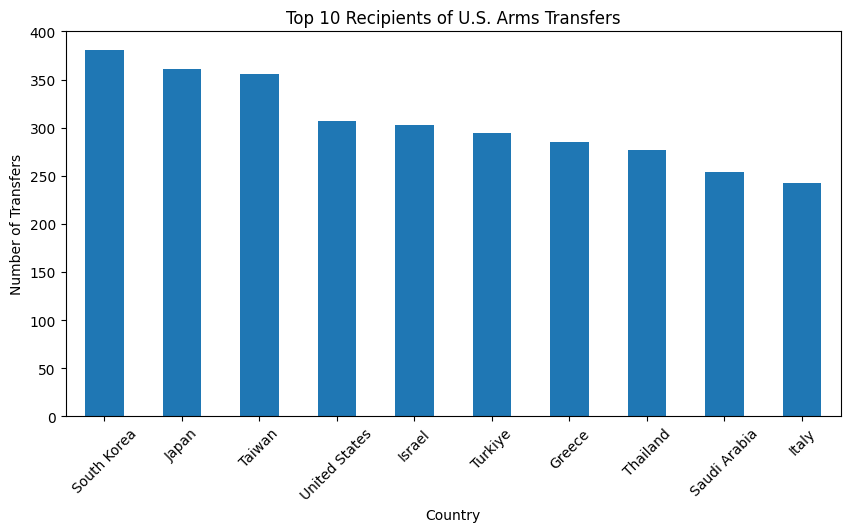

In [21]:
#Which countires recieved the most US arms transfers
import matplotlib.pyplot as plt

top_recipients.plot(kind="bar", figsize=(10,5))

plt.title("Top 10 Recipients of U.S. Arms Transfers")
plt.xlabel("Country")
plt.ylabel("Number of Transfers")
plt.xticks(rotation=45)

plt.show()

In [22]:
#which wepons cat is exported the most
arms_df['Weapon description'].value_counts().head(10)

,count
Weapon description,
armoured personnel carrier,553
transport aircraft,540
helicopter,433
light transport aircraft,422
fighter/ground-attack aircraft,416
light helicopter,385
surface-to-air missile,314
long-range air-to-air missile,285
light aircraft,283


In [23]:
#which countries receive the greatest total military value
#add note: Think of it as measuring the size and quality of the toolbox, not how skilled the carpenter is.
arms_df.groupby("Recipient")["SIPRI TIV for total order"] \
.sum() \
.sort_values(ascending=False) \
.head(20)

,SIPRI TIV for total order
Recipient,
Japan,78457.94
Saudi Arabia,59005.28
United States,54622.98
Germany,50286.28
South Korea,49200.08
Israel,43671.13
Taiwan,40969.57
United Kingdom,39647.18
Turkiye,36038.63


In [24]:
#Which weapon systems have the highest total valu
arms_df.groupby("Weapon designation")["SIPRI TIV for total order"] \
.sum() \
.sort_values(ascending=False) \
.head(10)

,SIPRI TIV for total order
Weapon designation,
F-35A Lightning-2,51425.00
F-16C,21740.94
F-104G Starfighter,20793.92
F-16C Block-50,19282.00
F-4E Phantom-2,18450.00
F-16A,17274.96
F-15 Advanced Eagle,16467.00
F-15C Eagle,15732.00
C-130H Hercules,15282.96


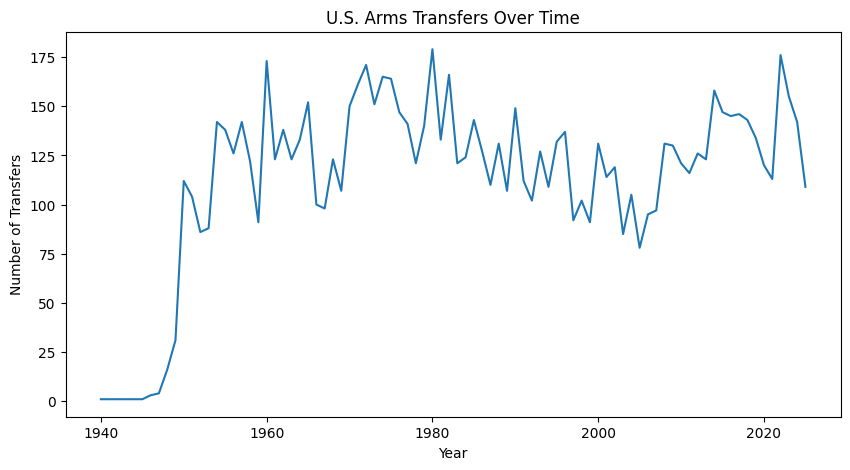

In [25]:
#How has U.S. arms transfer activity changed over time
orders_by_year = (
    arms_df.groupby("Year of order")
    .size()
)

orders_by_year.plot(figsize=(10,5))

plt.title("U.S. Arms Transfers Over Time")
plt.xlabel("Year")
plt.ylabel("Number of Transfers")

plt.show()

In [26]:
long_term_recipients = (
    arms_df.groupby("Recipient")["Year of order"]
    .agg(["min", "max", "count", "nunique"])
    .sort_values("nunique", ascending=False)
)

long_term_recipients.head(15)

,min,max,count,nunique
Recipient,,,,
South Korea,1949,2024,381,74
Taiwan,1951,2025,356,73
Thailand,1946,2025,277,73
Japan,1951,2025,361,72
Italy,1948,2025,242,70
Greece,1949,2024,285,70
Turkiye,1949,2024,294,70
United States,1947,2025,307,69
Australia,1950,2025,211,67


In [27]:
arms_df["status"].value_counts()

,count
status,
New,6997
Second hand,2594
Second hand but modernized,150


In [28]:
import os
os.listdir()

['.config',
 'arms_transfers_clean.csv',
 'arms_transfers_final_clean.csv',
 'sample_data']